# The Physics of Dipole Sources — an FDTDX Tutorial

This notebook is a self-contained introduction to **dipole sources** in electromagnetics, and to how they are
realized inside a **Finite-Difference Time-Domain (FDTD)** simulation using the
**FDTDX** package (a JAX-based, GPU-capable FDTD solver).

We will:

1. Build up the physics of an oscillating electric dipole from Maxwell's equations — near field, far field, and
   the characteristic radiation pattern.
2. See how FDTDX turns that physics into a single line of code: `fdtdx.PointDipoleSource`.
3. Explain *why* a radiating source needs **Perfectly Matched Layer (PML)** absorbing boundaries on every side of
   the simulation box.
4. Build a minimal simulation: **one dipole, sitting in the exact center of a vacuum box, surrounded by PML.**
5. Run it and render video.


## 1. What *is* a dipole source, and why does it matter?

The simplest possible radiating object is not a wire, an antenna, or a lamp — it is a single pair of opposite
charges $+q$ and $-q$, separated by a small, oscillating distance $d(t)$. Their **dipole moment**

$$ \mathbf{p}(t) = q\, \mathbf{d}(t) $$

is the source term that, once it starts to *accelerate* (i.e. once $\ddot{\mathbf p} \neq 0$), radiates
electromagnetic waves. Equivalently, we can describe the same physics as a tiny current element: a short wire of
length $\ell$ carrying a time-harmonic current $I(t) = I_0\cos(\omega t)$ has dipole moment
$p(t) = \int I(t)\,dt \cdot \ell$. This idealization — a point-like, oscillating current confined to a region far
smaller than the wavelength — is called the **Hertzian dipole** or **infinitesimal dipole**, after Heinrich Hertz,
who used exactly this kind of oscillator to first generate and detect radio waves in 1887.

Why bother with such an idealized object?

- **It is the elementary radiator.** Any localized current distribution — an antenna, a molecule, a quantum
  emitter, a scatterer illuminated by light — can be decomposed into a sum (a *multipole expansion*) of
  dipole, quadrupole, octupole, ... terms. The dipole term is almost always the dominant one.
- **It is the impulse response of Maxwell's equations.** In the same way that a delta function is the building
  block for arbitrary signals via convolution, a point dipole is the building block ("Green's function") for the
  field of an arbitrary current distribution: superpose enough dipoles with the right phase and amplitude and you
  can reconstruct *any* source.
- **It models real emitters.** Atoms, molecules, fluorescent markers, and semiconductor quantum dots all radiate
  (to excellent approximation) as oscillating electric dipoles. In nanophotonics, a `PointDipoleSource` is the
  standard way to simulate spontaneous emission, compute the local density of states (LDOS), or estimate the
  **Purcell factor** of a photonic cavity.
- **It is the simplest source that forces you to think in 3D.** Unlike a plane wave, which travels in one
  direction, a dipole radiates in *all* directions at once — which is exactly why we will need absorbing
  boundaries on every wall of the simulation box (Section 4).


## 2. From Maxwell's equations to a radiation pattern

*(If you want the full derivation of Maxwell's equations and the Yee-grid FDTD algorithm first, see the FDTDX
[Maxwell's Equations](https://fdtdx.readthedocs.io/en/latest/notebooks/physics/01_maxwell.html) and
[FDTD Method](https://fdtdx.readthedocs.io/en/latest/notebooks/physics/02_fdtd.html) notebooks — this section
only covers what is specific to dipole sources.)*

A dipole is a *source* term in Maxwell's equations, entering through the free current density $\mathbf J$ in the
Ampère–Maxwell law:

$$ \nabla \times \mathbf H = \mathbf J + \frac{\partial \mathbf D}{\partial t} $$

For a point dipole located at the origin, oscillating along a unit vector $\hat{\mathbf p}$ at angular frequency
$\omega$, the current density is a delta function in space:

$$ \mathbf J(\mathbf r, t) = \hat{\mathbf p}\, I_0 \cos(\omega t)\, \delta^3(\mathbf r) $$

Solving Maxwell's equations for this source (a classic result of antenna theory) gives an *exact* field with three
terms that scale as $1/r$, $1/r^2$, and $1/r^3$ with distance $r$ from the dipole:

- **Near field ($r \ll \lambda$):** the $1/r^2$ and $1/r^3$ terms dominate. This is essentially the quasi-static
  field of an oscillating charge dipole — it stores energy but does not (on average) carry it away to infinity.
- **Far field / radiation zone ($r \gg \lambda$):** only the $1/r$ term survives. This term falls off exactly
  like a spherical wave's amplitude must, so that the *power* it carries through a sphere of radius $r$
  ($\propto |\mathbf E|^2 \times 4\pi r^2$) stays constant — energy conservation for a wave spreading outward.
- **Transition region:** the crossover between these regimes happens around $r \sim \lambda / 2\pi$, sometimes
  called the *radianlength*.

The angular shape of the far-field radiation is the single most recognizable feature of a dipole: the radiated
power follows

$$ P(\theta) \;\propto\; \sin^2\theta $$

where $\theta$ is measured from the dipole axis. This produces a **doughnut-shaped (toroidal) radiation
pattern**: zero power straight along the dipole's axis ($\theta = 0$ or $180^\circ$), and maximum power broadside,
perpendicular to the dipole ($\theta = 90^\circ$). We will watch exactly this pattern emerge from the FDTD
simulation below. As a bonus fact: the strong $\omega^4$ frequency-scaling of dipole-radiated *power* (for a
fixed dipole moment amplitude) is the same physics behind Rayleigh scattering — the reason the sky is blue.


## 3. Turning a dipole into an FDTD source

FDTD does not solve Maxwell's equations in closed form — it marches the fields forward in time on a discrete,
staggered (Yee) grid, updating $\mathbf E$ and $\mathbf H$ in a leap-frog fashion at every grid cell. A dipole
source is injected by literally adding the current term $\mathbf J$ from the Ampère–Maxwell law into the update
equation at **one single Yee cell**, every time step. This is exactly what `fdtdx.PointDipoleSource` does; from
the FDTDX source code, the electric-dipole update is

$$ E_i[x,y,z] \;\mathrel{+}=\; -c\,\big(\varepsilon^{-1} \hat{\mathbf p}\big)_i \cdot \text{amplitude} \cdot
\text{temporal}(t) $$

A few things worth unpacking here, because each one is a deliberate physics choice:

- **It is a "soft" source.** The source *adds* to whatever field is already present at that cell, rather than
  overwriting it. A "hard" source (field = value) would act like a tiny perfect reflector sitting at the dipole
  location, bouncing any wave that later passes back through that point. A soft source lets scattered or
  reflected light pass straight through, which is essential if you later add objects near the dipole (e.g. to
  study how a nearby mirror changes its emission rate).
- **`polarization`, `azimuth_angle`, `elevation_angle`** set the direction $\hat{\mathbf p}$ of the dipole moment
  — the axis of the "doughnut" from Section 2.
- **`wave_character`** sets the oscillation frequency $\omega$ (equivalently wavelength or period) — this is the
  "temporal(t)" envelope, by default a smoothly ramped continuous wave (`SingleFrequencyProfile`), so the source
  doesn't switch on with a numerically-harsh step that would inject spurious broadband noise.
- **`source_type="electric"` vs `"magnetic"`** switches between an electric dipole (injects into the $\mathbf E$
  update, as above) and a magnetic dipole (the dual operation on $\mathbf H$) — useful for modeling magnetic
  emitters or, in metamaterial work, artificial magnetic resonances.

Everything else about building the simulation is just geometry and bookkeeping — which is what the rest of this
notebook demonstrates.


## 4. Why we need PML *on every side*

FDTD needs a **finite** computational box, but Maxwell's equations for a dipole in free space are defined on an
**infinite** domain. If we simply stopped the grid at some boundary (e.g. forced the field to zero there), the
outgoing spherical wave would reflect off that artificial wall and travel back into the simulation, corrupting
the result with numerical echoes.

The standard fix is the **Perfectly Matched Layer (PML)**: a layer of artificial, graded, lossy material placed
around the computational domain. A properly-tuned PML is *impedance-matched* to the interior — a wave crossing
into it, at any angle of incidence and any frequency, sees no material discontinuity to reflect from — and it
attenuates the wave exponentially as it propagates through the layer's thickness, so that by the time it would
reach the true outer edge of the grid its amplitude is numerically negligible. `fdtdx.BoundaryConfig` implements
a *complex-frequency-shifted* PML (visible in its `sigma`, `kappa` and `alpha` grading parameters), which is
particularly good at absorbing both propagating waves and the slowly-decaying evanescent near-field components
that sit close to a source.

For a **directional** source like a plane wave, you often only need PML on the side the wave is heading toward
(the other sides can use periodic or symmetry boundaries). A **dipole radiates outward in every direction at
once**, so this time we need absorbing PML boundaries on **all six faces** of the box:

```python
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(thickness=10, boundary_type="pml")
```

`from_uniform_bound` is a shortcut that applies the same PML settings to $\pm x, \pm y, \pm z$ in one call — no
need to configure all six faces by hand.


## 5. Setting up the simulation

Let's build exactly the scene described above: an empty (vacuum) cubic simulation volume, PML on all six walls,
and a single electric dipole sitting at the exact center. First, the imports.


In [74]:
import time

import fdtdx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pytreeclass as tc
from IPython.display import HTML, Video

%matplotlib inline


### 5.1 Simulation configuration

We pick a wavelength in the near-infrared (1550 nm, a common wavelength in photonics) purely as a convenient,
round number — the physics is identical at any wavelength as long as the grid resolves it well. A good rule of
thumb for FDTD accuracy is **at least 10–20 grid cells per wavelength**; we use 16 here.

We also explicitly set `backend="cpu"` so that this notebook runs anywhere out of the box. If you have an NVIDIA
or AMD GPU installed (and installed `fdtdx[cuda12]` / `fdtdx[rocm]`), switch this to `"gpu"` — the simulation
below is small, but larger 3D dipole/antenna problems benefit enormously from GPU acceleration.


In [77]:
# A random key is required by FDTDX even for a fully deterministic simulation like this one
key = jax.random.PRNGKey(42)

WAVELENGTH = 1.55e-6          # 1550 nm
SPEED_OF_LIGHT = 299_792_458.0

config = fdtdx.SimulationConfig(
    time=90e-15,                    # total simulated time: long enough for the wave to cross the whole box
    grid=fdtdx.UniformGrid(spacing=WAVELENGTH / 16),     # ~16 grid cells per wavelength
    backend="cpu",                  # switch to "gpu" if you have one installed
    dtype=jnp.float32,
    courant_factor=0.99,
)

### 5.2 The simulation volume (vacuum) and PML boundaries

`object_list` collects every physical object in the scene; `constraints` collects the rules FDTDX uses to resolve
their exact positions and sizes on the Yee grid (see the
[Object Placement Guide](https://fdtdx.readthedocs.io/en/latest/notebooks/quickstart/03_object_placement_guide.html)
for the full mechanics). The simulation volume itself doubles as the background material — here, vacuum
($\varepsilon_r = \mu_r = 1$) everywhere.


In [80]:
object_list = []
constraints = []

VOLUME_SIZE = 10e-6   # 10 micron cube -> about 6.5 wavelengths across

volume = fdtdx.SimulationVolume(
    partial_real_shape=(VOLUME_SIZE, VOLUME_SIZE, VOLUME_SIZE),
    material=fdtdx.Material(permittivity=1.0, permeability=1.0),   # vacuum background
)
object_list.append(volume)


In [82]:
# PML absorbing boundaries on all six faces (+x, -x, +y, -y, +z, -z)
bound_cfg = fdtdx.BoundaryConfig.from_uniform_bound(thickness=10, boundary_type="pml")
bound_dict, bound_constraints = fdtdx.boundary_objects_from_config(bound_cfg, volume)

object_list.extend(bound_dict.values())
constraints.extend(bound_constraints)


### 5.3 The dipole, placed exactly at the center

We orient the dipole along $z$ (`polarization=2`) and drive it at a single frequency corresponding to our chosen
wavelength. `place_at_center(volume)` is the constraint that pins the dipole to the geometric center of the
simulation volume — the middle of the box, equidistant from every PML wall.


In [85]:
dipole = fdtdx.PointDipoleSource(
    name="Dipole",
    wave_character=fdtdx.WaveCharacter(wavelength=WAVELENGTH),
    polarization=2,          # 0=x, 1=y, 2=z -> the dipole oscillates along z
    source_type="electric",
    amplitude=1.0,
)
object_list.append(dipole)
constraints.append(dipole.place_at_center(volume))


### 5.4 Detectors — so we have something to watch

Running the simulation only advances $\mathbf E$ and $\mathbf H$ arrays in memory; to actually *see* the radiated
field, we attach detectors that record snapshots as the simulation progresses. We use

- **`EnergyDetector`** (`as_slices=True`) spanning the whole volume. Energy density
   $u \propto \varepsilon |\mathbf E|^2 + \mu |\mathbf H|^2$ is always positive, so this shows the expanding
   spherical wavefront as a growing bright ring/shell.


In [88]:
# Whole-volume energy density, for the overall spreading wavefront
energy_detector = fdtdx.EnergyDetector(
    name="EnergyVideo",
    as_slices=True,                       # memory-efficient: only store 2D cut-planes, not the full 3D cube
    switch=fdtdx.OnOffSwitch(interval=4),
    exact_interpolation=True,
    num_video_workers=4,
)
object_list.append(energy_detector)
constraints.extend(energy_detector.same_position_and_size(volume))

### 5.5 Resolving the scene and sanity-checking the geometry

`fdtdx.place_objects` takes every object and every constraint and solves for concrete grid positions and sizes.
`fdtdx.plot_setup` then draws the resolved geometry — this is the moment to visually confirm the dipole really is
centered, with a uniform ring of PML around the outside, *before* spending time running the simulation.


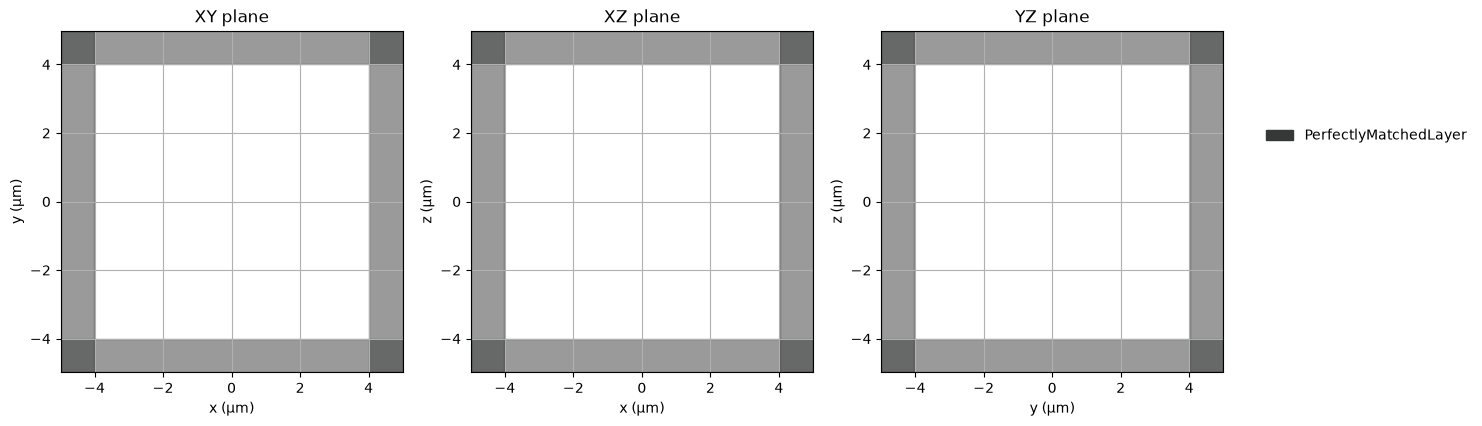

┌───────────────────────────┬──────────────────┬──────────┬───────┐
│Name                       │Type              │Count     │Size   │
├───────────────────────────┼──────────────────┼──────────┼───────┤
│.fields                    │FieldState        │9,102,522 │34.72MB│
├───────────────────────────┼──────────────────┼──────────┼───────┤
│.inv_permittivities        │f32[1,103,103,103]│1,092,727 │4.17MB │
├───────────────────────────┼──────────────────┼──────────┼───────┤
│.inv_permeabilities        │float             │1         │       │
├───────────────────────────┼──────────────────┼──────────┼───────┤
│.detector_states           │dict              │3,882,894 │14.81MB│
├───────────────────────────┼──────────────────┼──────────┼───────┤
│.recording_state           │NoneType          │          │       │
├───────────────────────────┼──────────────────┼──────────┼───────┤
│.electric_conductivity     │NoneType          │          │       │
├───────────────────────────┼──────────────────┼

In [91]:
key, subkey = jax.random.split(key)
objects, arrays, params, config, _ = fdtdx.place_objects(
    object_list=object_list,
    config=config,
    constraints=constraints,
    key=subkey,
)

fig = fdtdx.plot_setup(
    config=config,
    objects=objects,
    exclude_object_list=[energy_detector, radiation_pattern_detector],
)
plt.show()

# Optional: a quick look at where the simulation's memory is going
print(tc.tree_summary(arrays, depth=1))


## 6. Running the simulation

Running an FDTDX simulation is a two-step process: `fdtdx.apply_params` resolves any parametric objects and
precomputes values used throughout the run, and `fdtdx.run_fdtd` performs the actual leap-frog time-stepping loop
described in Section 3. We wrap both in a single function so JAX can trace and JIT-compile the whole simulation —
the compiled function can then be re-run instantly for, e.g., a different dipole position or frequency.


In [94]:
def sim_fn(params, arrays, key):
    arrays, new_objects, _ = fdtdx.apply_params(arrays, objects, params, key)
    final_state = fdtdx.run_fdtd(
        arrays=arrays,
        objects=new_objects,
        config=config,
        key=key,
    )
    _, arrays = final_state
    return arrays


In [96]:
start_time = time.time()
jitted_sim_fn = jax.jit(sim_fn).lower(params, arrays, key).compile()
print(f"Compilation time: {time.time() - start_time:.2f} s")


Compilation time: 0.45 s


In [98]:
start_time = time.time()
new_arrays = jitted_sim_fn(params, arrays, subkey)
print(f"Simulation runtime: {time.time() - start_time:.2f} s")


FDTD (checkpointed):   0%|                            | 0/487 [00:00<?, ?step/s]

Simulation runtime: 2.30 s


## 7. Watching the dipole radiate

The detector's `draw_plot` method turns its recorded time series into a video (since the data varies over both
space and time) and returns the path(s) to the rendered file(s), which we embed directly below.

### 7.1 Energy density — the expanding wavefront

Watch for a bright ring of energy expanding outward from the center at a constant speed (the speed of light) —
this is the direct FDTD analogue of the "ripples on a pond" picture of a radiating source, and a nice visual
check that the PML at the edges is absorbing the wave rather than reflecting it back inward.


In [101]:
energy_video_paths = objects["EnergyVideo"].draw_plot(new_arrays.detector_states["EnergyVideo"])
print(energy_video_paths)
Video(list(energy_video_paths.values())[0], embed=True, width=720)


{'sliced_video': '/var/folders/9c/sf1_5nb17v51rk1l8xcxshdc0000gn/T/tmp5elt7kb0.mp4'}
